**Implementación de modelos supervisados (regresión) con Scikit-learn.**

El objetivo principal de este notebook es generar, entrenar y evaluar modelos de aprendizaje supervisado, específicamente LinearRegression y DecisionTreeRegressor orientados a predecir diferentes variables objetivo continuas presentes en nuestro conjunto de datos como deuda_total, gasto_mensual, score_crediticio e ingreso_mensual. 

La selección final del modelo y del objetivo ideal se justifica comparando el desempeño en el conjunto de prueba a través de métricas de regresión, buscando el algoritmo que logre maximizar la varianza explicada ($R^2$) y minimizar el error absoluto (MAE).

### Requisitos de software: este notebook fue desarrollado usando Python 3.14 y las siguientes librerías necesarias:

* pandas 3.0.2
* matplotlib 3.10.9
* scikit-learn (sklearn) 1.8.0

### Importe de librerías necesarias


In [161]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree


In [162]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocesamiento.data_preprocessing import corregir_valores_negativos
from preprocesamiento.data_preprocessing import detectar_inconsistencias
from preprocesamiento.data_preprocessing import separar_objetivo_features
from preprocesamiento.data_preprocessing import eliminar_nulos_objetivo
from preprocesamiento.pipelines import aplicar_pipeline_limpieza_train_test
from preprocesamiento.pipelines import build_cleaning_pipeline_reg
from preprocesamiento.pipelines import build_decision_tree_regressor_pipeline
from preprocesamiento.pipelines import build_linear_regression_pipeline
from preprocesamiento.pipelines import build_preprocessor
from model_evaluation import evaluar_regresor
from model_training import entrenar_modelo

### Carga de Datos

In [163]:
url = "https://raw.githubusercontent.com/ramirezluna-david/proyecto_modelado_grp2/rama_david/data/dataset_clientes.csv"
data = pd.read_csv(url)

### Preprocesamiento de datos

#### Detección de inconsistencias

In [164]:
# Detección de inconsistencias: valores negativos o ceros en columnas que deberían ser positivas.
conteo_negativos, conteo_ceros = detectar_inconsistencias(data)

Negativos detectados: {'ingreso_mensual': 11, 'gasto_mensual': 68, 'deuda_total': 143}
Ceros detectados: ninguno


In [165]:
# Tratamiento: corrige valores negativos convirtiéndolos a valores absolutos.
data = corregir_valores_negativos(data)

Valores negativos corregidos a valores absolutos en las columnas relevantes.


# 1. Modelamiento para variable objetivo "deuda_total"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [166]:
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data,
    target="deuda_total",
 )

## Construcción de arrays para procesamiento

In [167]:
numerical_features = ["gasto_mensual", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [168]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "deuda_total"

### Pipeline para Regresión Lineal

In [169]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [170]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.714855,-0.797540,-0.834358,1.704040,0.748802,-0.719029,-0.199397,0.713197,1.682645,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.010107,0.828254,0.437210,-0.984267,0.309645,1.112076,0.201196,0.006011,0.810526,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
2,0.101127,1.820609,0.220017,0.695925,-0.568671,-1.085250,1.670040,-1.408361,0.229113,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,0.622061,-0.594846,0.253618,-1.264299,-0.188067,-0.902140,-1.515634,0.006011,-1.660479,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0
4,-0.498981,0.055956,-0.971876,-0.088165,0.075427,0.013413,-1.429793,1.420383,-1.515125,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [171]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [172]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((16000, 8), (4000, 8))

### Entrenamiento


In [173]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [174]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 678,214


In [175]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [176]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=7):
- abandono_0
- num_productos
- dia_semana_registro_Lunes
- hora_registro
- dia_semana_registro_Viernes
- dia_semana_registro_Jueves
- genero_Masculino


## Modelo DecisionTreeRegressor para "deuda_total"

### Pipeline para DecisionTreeRegressor

In [177]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [178]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.714855,-0.797540,-0.834358,1.704040,0.748802,-0.719029,-0.199397,0.713197,1.682645,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.010107,0.828254,0.437210,-0.984267,0.309645,1.112076,0.201196,0.006011,0.810526,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
2,0.101127,1.820609,0.220017,0.695925,-0.568671,-1.085250,1.670040,-1.408361,0.229113,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,0.622061,-0.594846,0.253618,-1.264299,-0.188067,-0.902140,-1.515634,0.006011,-1.660479,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0
4,-0.498981,0.055956,-0.971876,-0.088165,0.075427,0.013413,-1.429793,1.420383,-1.515125,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


In [179]:
target = "deuda_total"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "num_productos", 
    "dia_semana_registro_Lunes", 
    "hora_registro",
    "dia_semana_registro_Viernes",
    "dia_semana_registro_Jueves",
    "genero_Masculino"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [180]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((16000, 8), (4000, 8))

### Entrenamiento

In [181]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [182]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.009
MAE   : 684,001


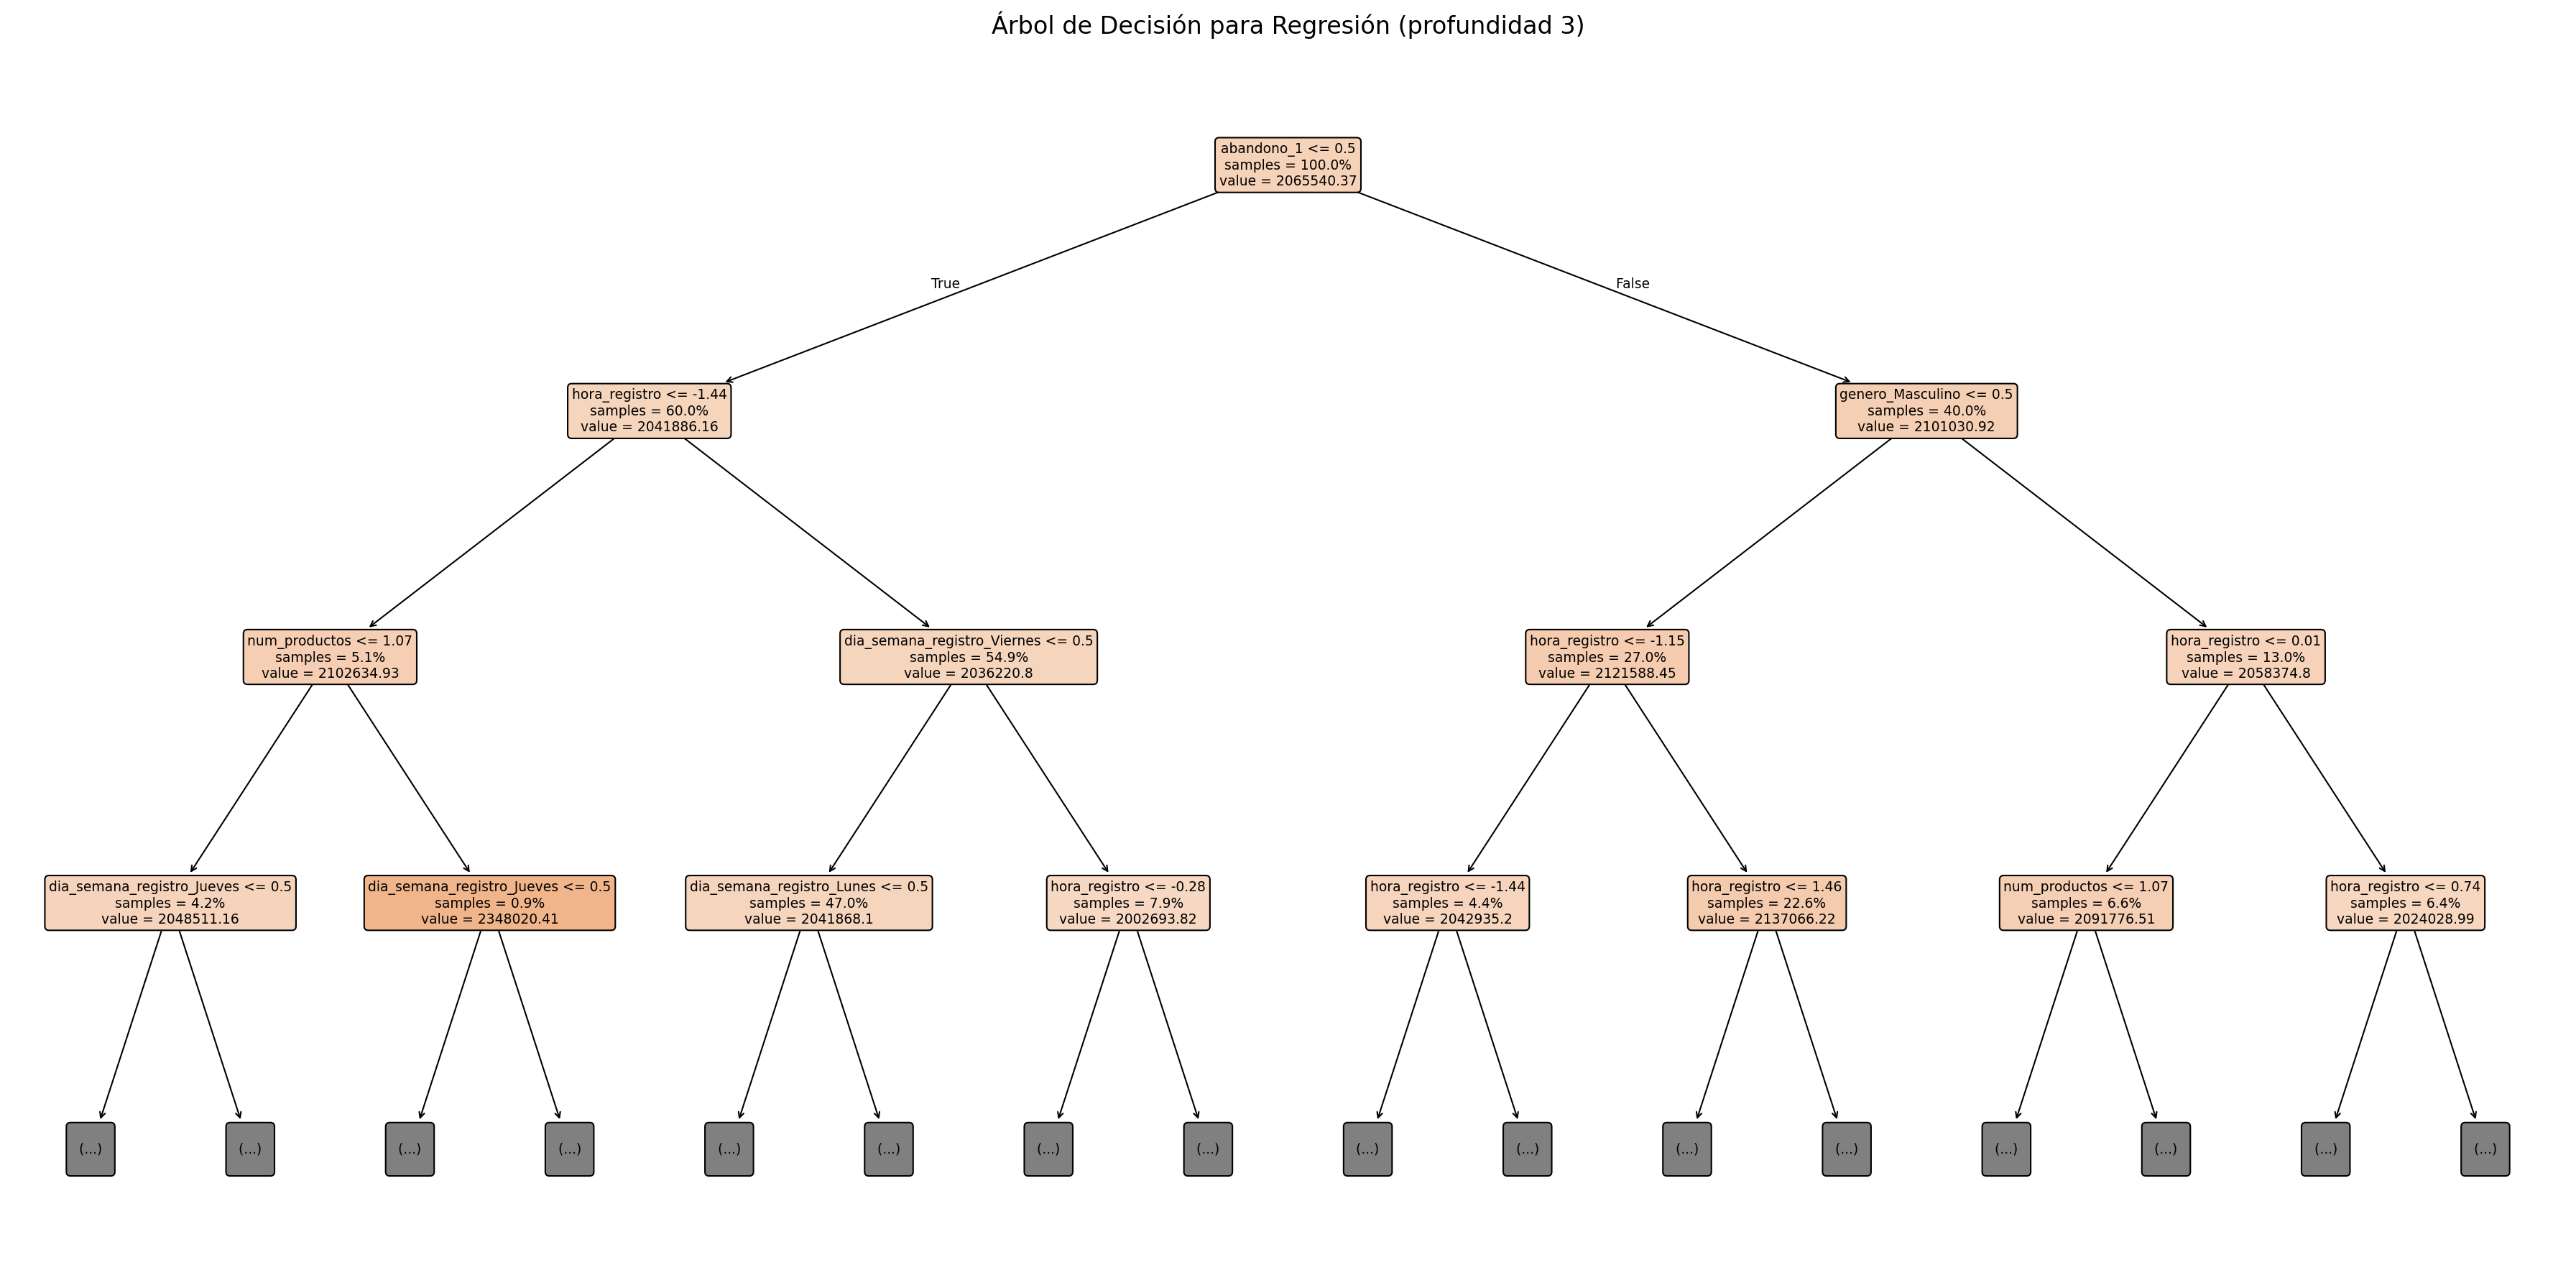

In [183]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 2. Modelamiento para variable objetivo "gasto_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [184]:
data_filtrada = eliminar_nulos_objetivo(data, target="gasto_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="gasto_mensual",
 )

In [185]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [186]:
numerical_features = ["deuda_total", "score_crediticio", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [187]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "gasto_mensual"

### Pipeline para Regresión Lineal

In [188]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [189]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.397639,-0.194112,-0.177909,0.533434,0.838486,-0.915482,-0.574637,0.002288,0.803048,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,0.434478,0.290352,-0.389698,-0.697633,-0.357178,0.736145,-1.724756,-1.417333,-0.067703,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.608634,0.813164,-1.146468,1.037052,-0.473828,0.002089,0.689545,-1.417333,1.673799,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.772833,-0.579034,-0.973814,-1.704869,-0.969591,1.286687,-1.439603,1.421909,-0.067703,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,-0.545305,1.190941,-0.186973,-0.305930,0.021935,0.919659,1.345398,-0.707522,1.673799,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [190]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [191]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 10), (3800, 10))

### Entrenamiento


In [192]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [193]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : 0.001
MAE   : 119,185


In [194]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [195]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=9):
- abandono_0
- tipo_plan
- dia_semana_registro_Viernes
- region_Norte
- canal_registro_App
- dia_semana_registro_Jueves
- uso_app
- estado_civil_Soltero
- region_Sur


## Modelo DecisionTreeRegressor para "gasto_mensual"

### Pipeline para DecisionTreeRegressor

In [196]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [197]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,deuda_total,score_crediticio,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,-0.397639,-0.194112,-0.177909,0.533434,0.838486,-0.915482,-0.574637,0.002288,0.803048,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,0.434478,0.290352,-0.389698,-0.697633,-0.357178,0.736145,-1.724756,-1.417333,-0.067703,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.608634,0.813164,-1.146468,1.037052,-0.473828,0.002089,0.689545,-1.417333,1.673799,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-1.772833,-0.579034,-0.973814,-1.704869,-0.969591,1.286687,-1.439603,1.421909,-0.067703,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0
4,-0.545305,1.190941,-0.186973,-0.305930,0.021935,0.919659,1.345398,-0.707522,1.673799,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [198]:
target = "gasto_mensual"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1",
    "tipo_plan",
    "dia_semana_registro_Viernes", 
    "region_Norte", 
    "canal_registro_App", 
    "dia_semana_registro_Jueves",
    "uso_app",
    "estado_civil_Soltero",
    "region_Sur"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [199]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 10), (3800, 10))

### Entrenamiento

In [200]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [201]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.015
MAE   : 120,487


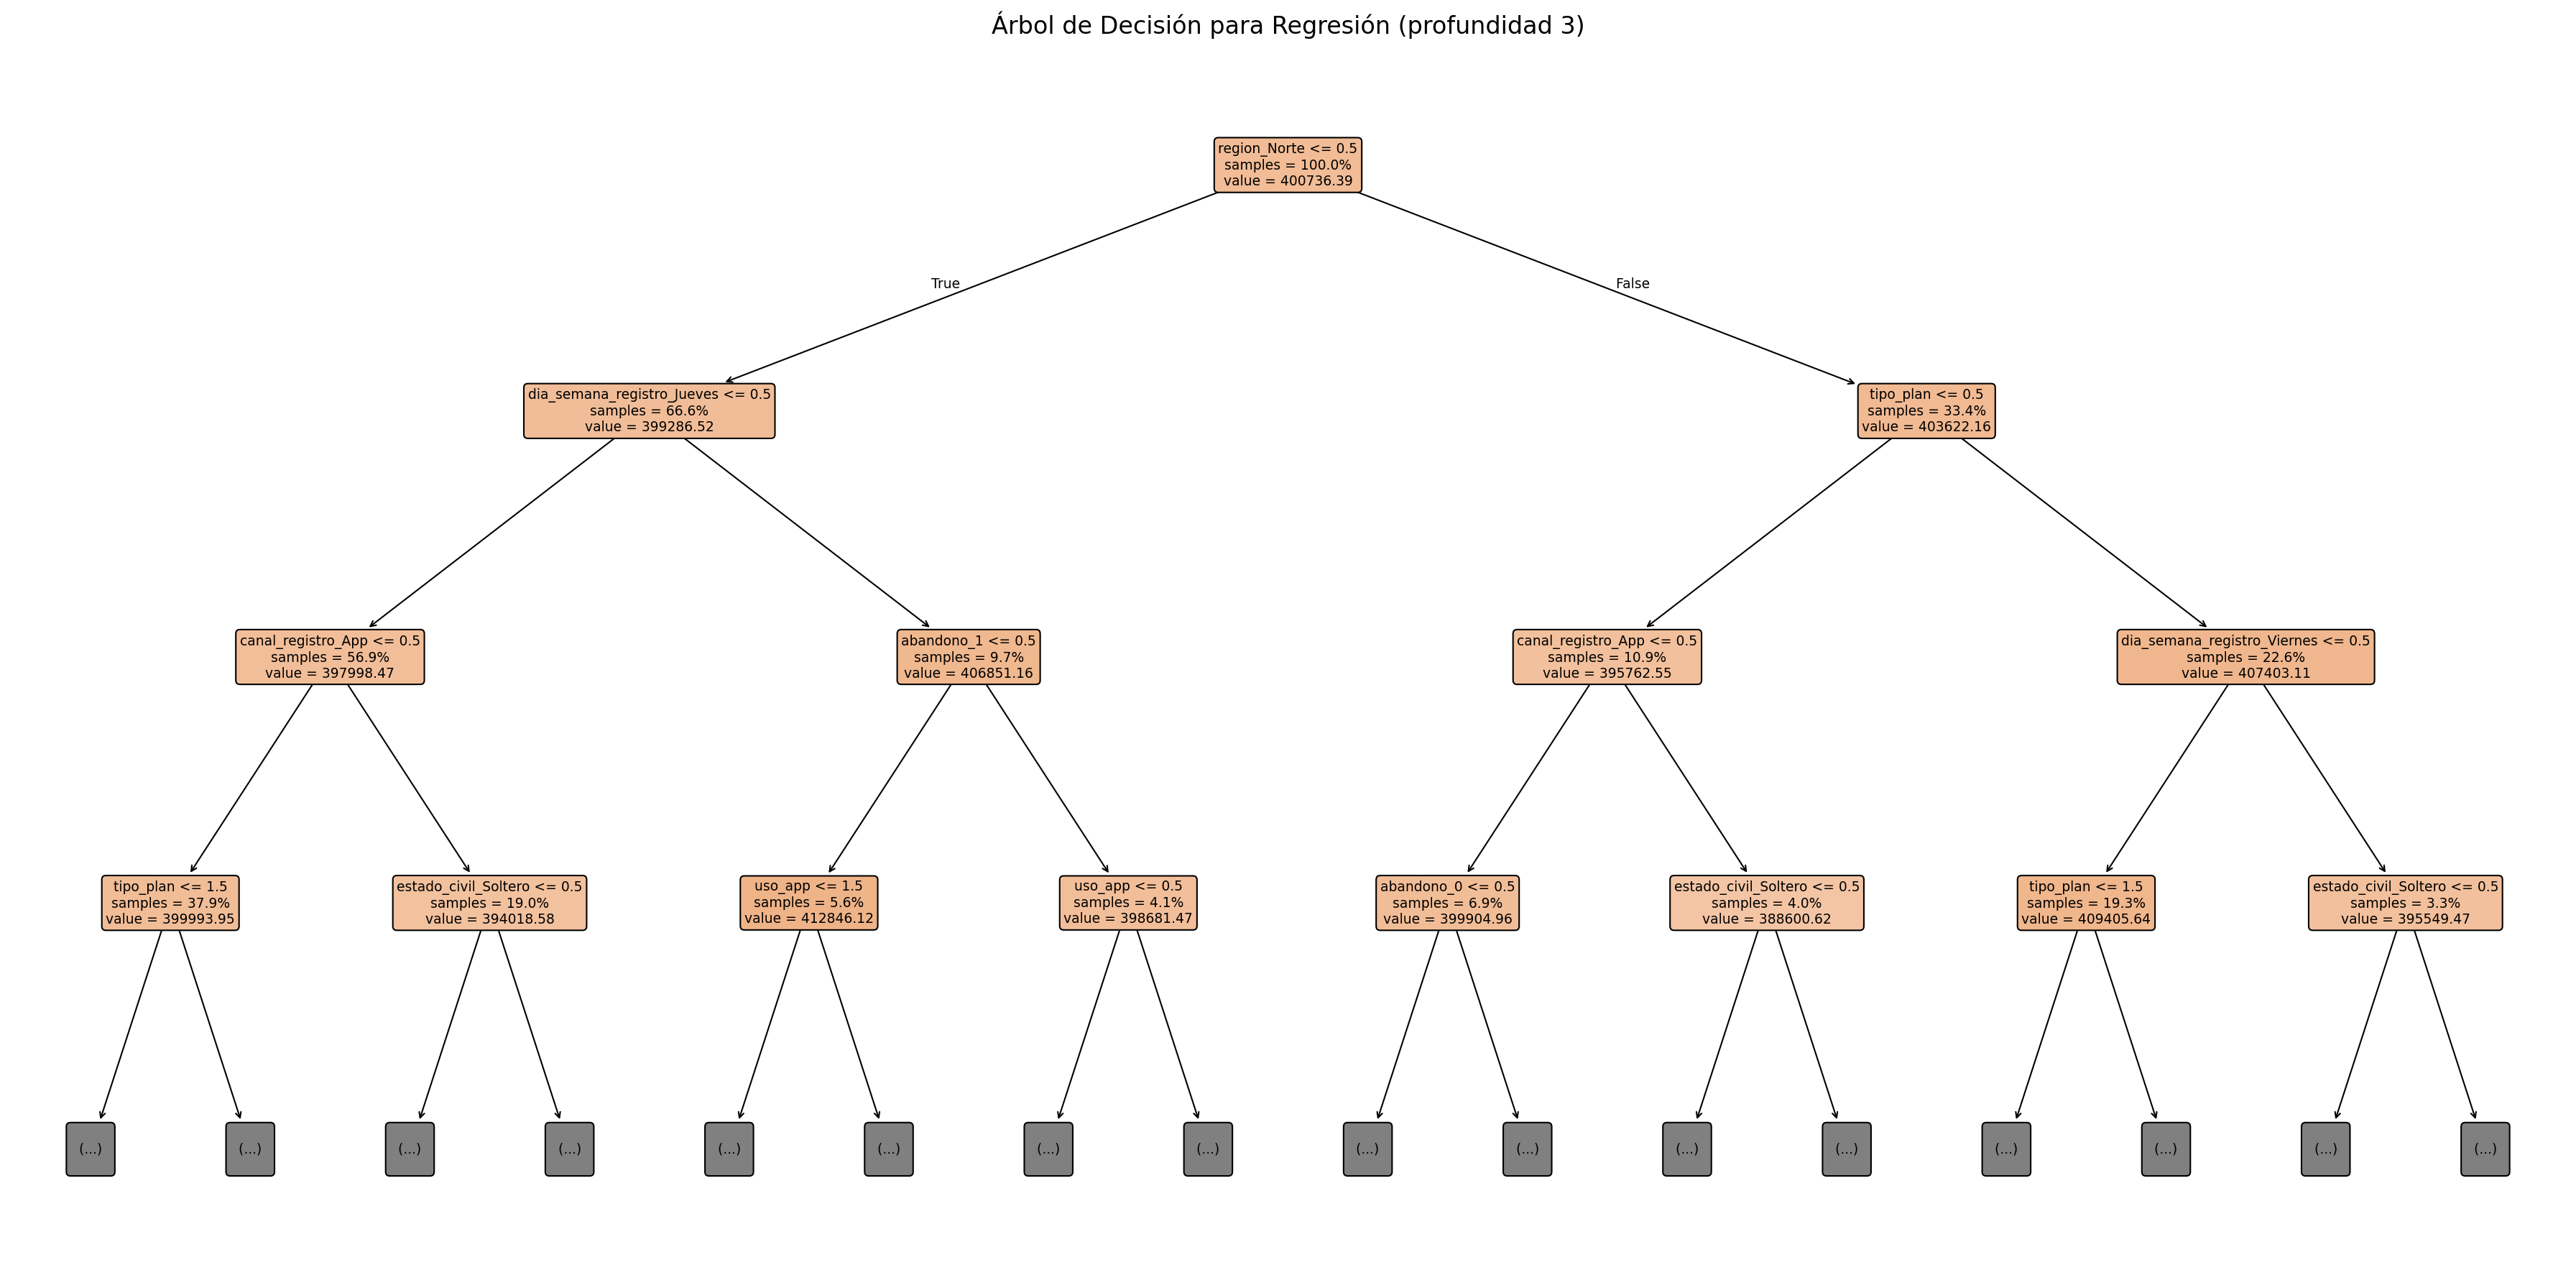

In [202]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 3. Modelamiento para variable objetivo "score_crediticio"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [203]:
data_filtrada = eliminar_nulos_objetivo(data, target="score_crediticio")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="score_crediticio",
 )

In [204]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [205]:
numerical_features = ["gasto_mensual", "deuda_total", "ingreso_mensual", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [206]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "score_crediticio"

### Pipeline para Regresión Lineal

In [207]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [208]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,0.293961,-0.101564,2.729697e-16,0.753985,-1.640221,-0.361492,-0.182680,1.417454,-1.365317,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0
1,1.859415,0.133182,-4.176288e-01,-1.598108,1.598447,-1.094239,-0.192187,1.417454,-0.640394,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
2,-0.356419,-0.551578,-2.099707e-02,1.033996,1.335853,-0.178306,0.454332,1.417454,0.229515,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.327925,-0.449012,-2.593404e-01,-0.758075,0.927372,1.470374,0.872667,0.709216,-0.930363,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
4,0.295857,0.974657,2.138803e-01,-1.374099,-1.027500,0.920814,0.587438,-1.415497,-0.060455,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [209]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [210]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 12), (3800, 12))

### Entrenamiento


In [211]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [212]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : 0.000
MAE   : 82


In [213]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- abandono_1


In [214]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=11):
- abandono_0
- hora_registro
- frecuencia_compra
- dia_semana_registro_Domingo
- ultima_compra_dias
- region_Sur
- region_Centro
- ingreso_mensual
- dia_semana_registro_Miercoles
- canal_registro_App
- edad


## Modelo DecisionTreeRegressor para "score_crediticio"

### Pipeline para DecisionTreeRegressor

In [215]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [216]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,ingreso_mensual,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,0.293961,-0.101564,2.729697e-16,0.753985,-1.640221,-0.361492,-0.182680,1.417454,-1.365317,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,2.0
1,1.859415,0.133182,-4.176288e-01,-1.598108,1.598447,-1.094239,-0.192187,1.417454,-0.640394,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
2,-0.356419,-0.551578,-2.099707e-02,1.033996,1.335853,-0.178306,0.454332,1.417454,0.229515,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.327925,-0.449012,-2.593404e-01,-0.758075,0.927372,1.470374,0.872667,0.709216,-0.930363,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
4,0.295857,0.974657,2.138803e-01,-1.374099,-1.027500,0.920814,0.587438,-1.415497,-0.060455,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [217]:
target = "score_crediticio"
mejores_variables_predictoras = [
    "abandono_0",
    "abandono_1", 
    "hora_registro", 
    "frecuencia_compra", 
    "dia_semana_registro_Domingo",
    "ultima_compra_dias",
    "region_Sur",
    "region_Centro",
    "ingreso_mensual",
    "dia_semana_registro_Miercoles",
    "canal_registro_App",
    "edad"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [218]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 12), (3800, 12))

### Entrenamiento

In [219]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [220]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.035
MAE   : 83


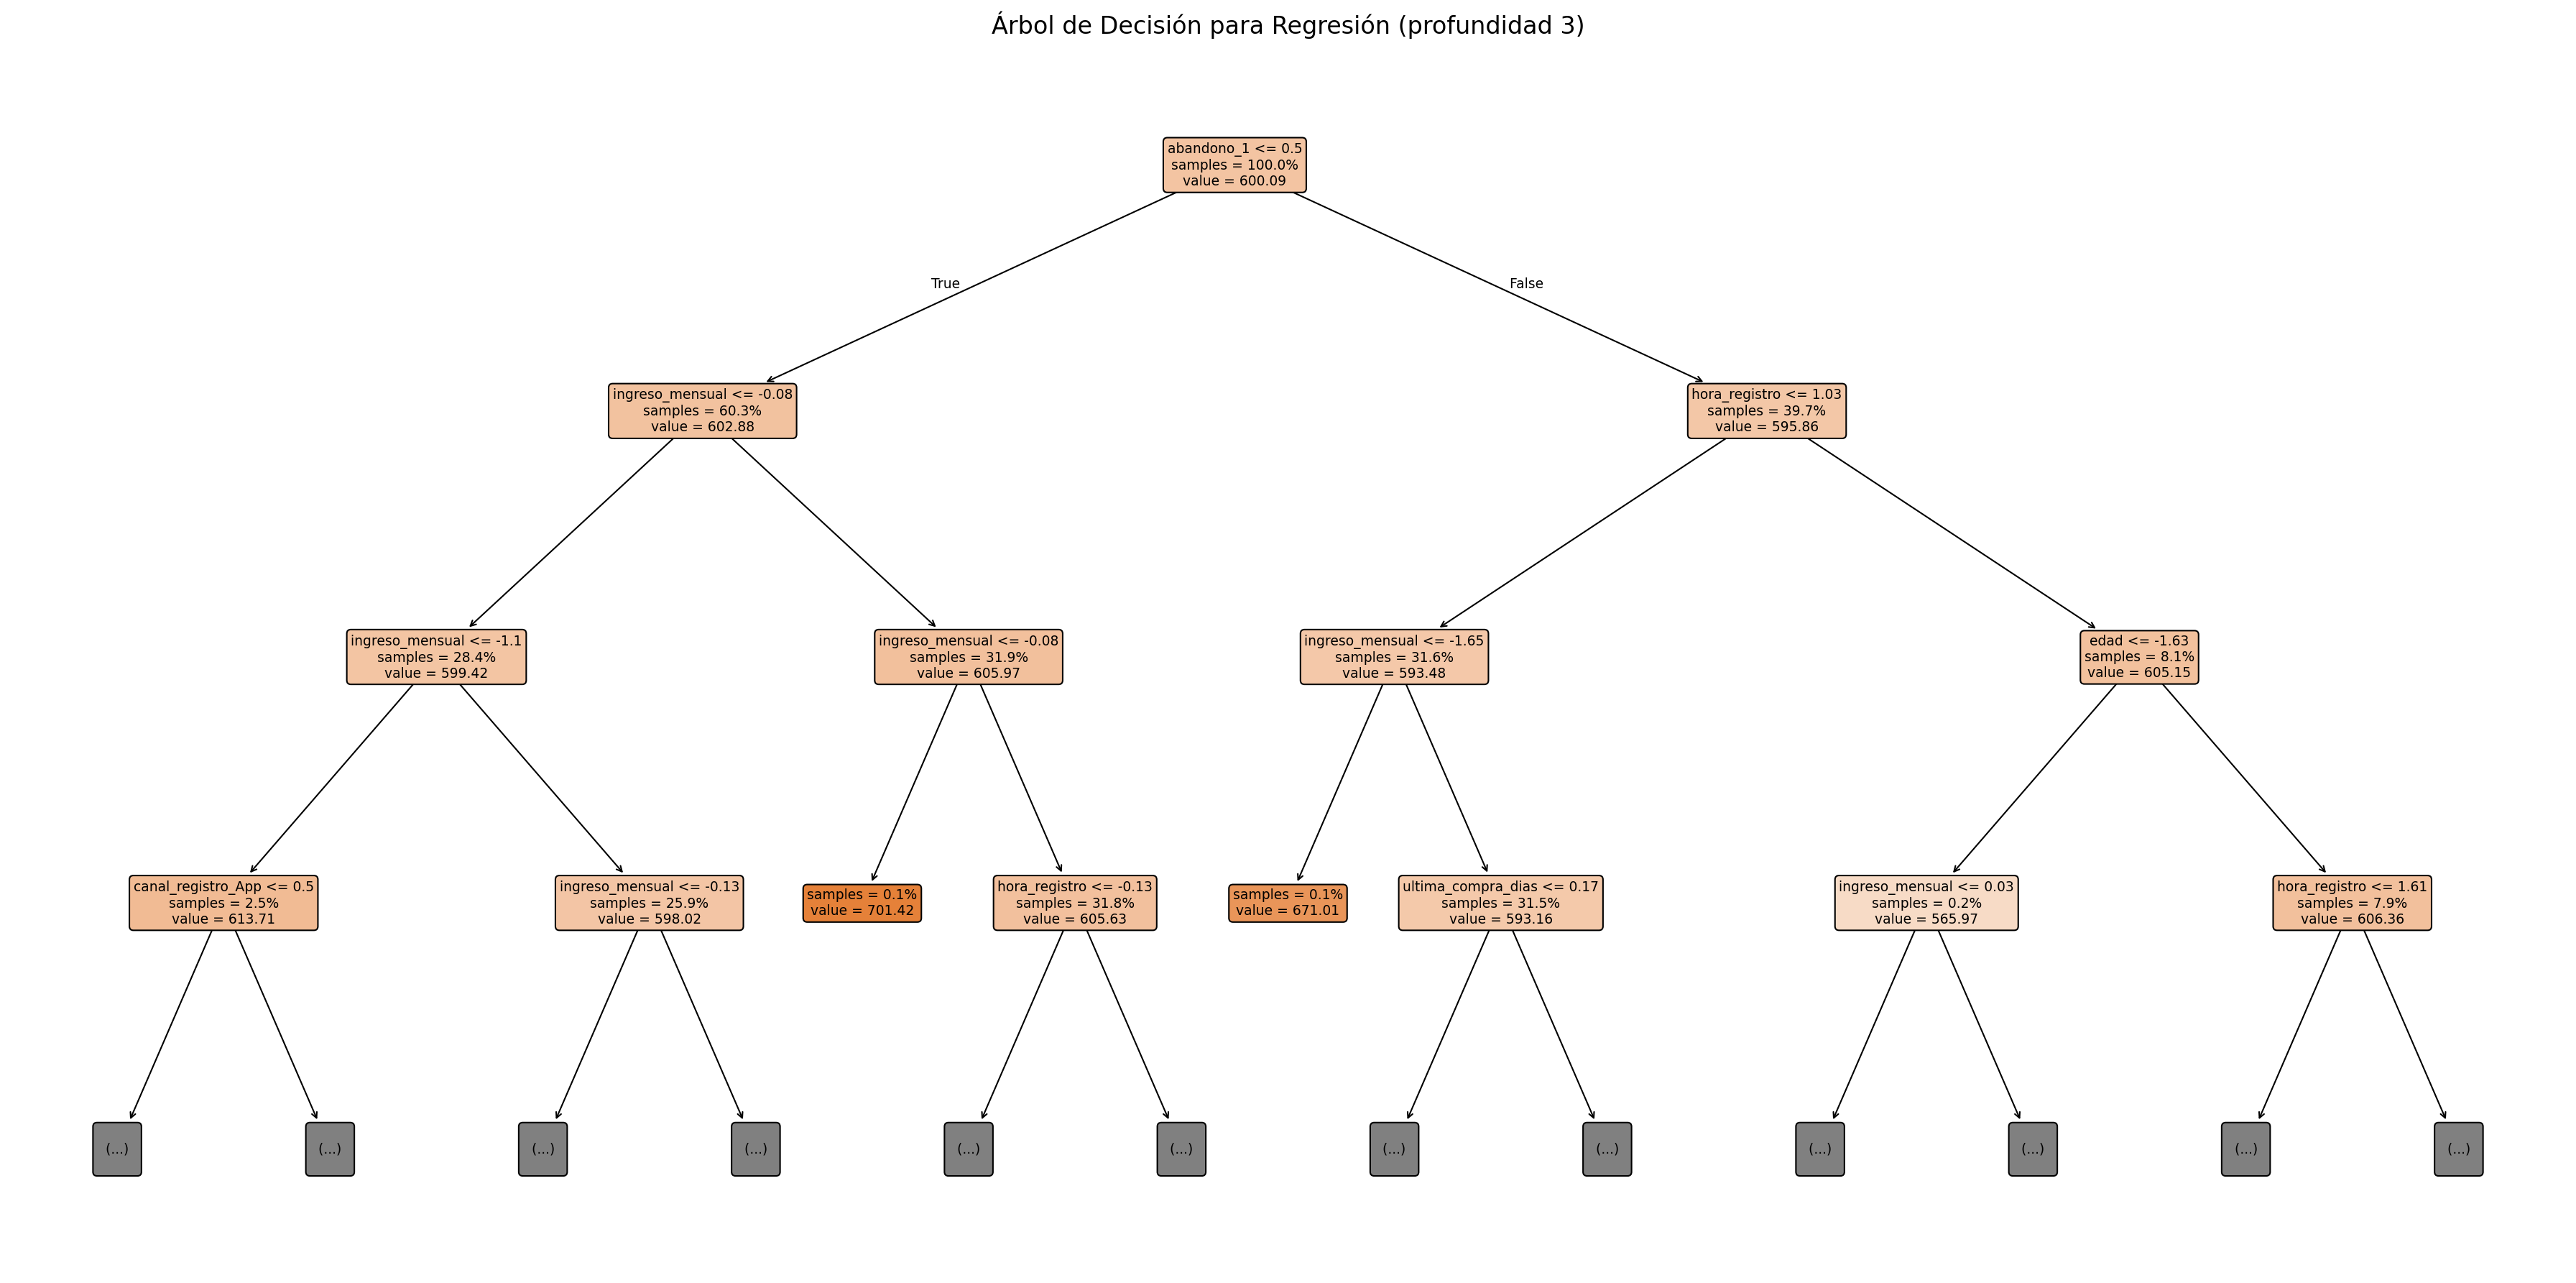

In [221]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()

# 4. Modelamiento para variable objetivo "ingreso_mensual"

## Elimina duplicados y separa objetivo/features para mantener alineacion

In [222]:
data_filtrada = eliminar_nulos_objetivo(data, target="ingreso_mensual")
data_sin_dup, var_dep, var_indep = separar_objetivo_features(
    data_filtrada,
    target="ingreso_mensual",
 )

In [223]:
# Verifica que no haya nulos en la variable objetivo
var_dep.isna().sum()

np.int64(0)

## Construcción de arrays para procesamiento

In [224]:
numerical_features = ["gasto_mensual", "deuda_total", "score_crediticio", "edad", "antiguedad_meses", "frecuencia_compra", "ultima_compra_dias", "num_productos", "hora_registro"] # Define listado de variables numéricas.
categorical_nominales = ["abandono", "tiene_tarjeta_credito", "genero", "region", "estado_civil", "canal_registro", "dia_semana_registro"] # Define listado de variables categóricas nominales.
categorical_ordinales = ["tipo_plan", "uso_app"] # Define listado de variables categóricas ordinales.
date_time_features = ["fecha_registro"] # Define listado de variables de fecha y hora.
orden_tipo_plan = ["Basico", "Estandar", "Premium"] # Define orden para variable ordinal tipo_plan.
orden_uso_app = ["Bajo", "Medio", "Alto"] # Define orden para variable ordinal uso_app.

## Integración de pipelines de transformación

In [225]:
pipeline_numerical_features, pipeline_nominales, pipeline_ordinales, preprocesador = build_preprocessor(
    numerical_features=numerical_features,
    categorical_nominales=categorical_nominales,
    categorical_ordinales=categorical_ordinales,
    orden_tipo_plan=orden_tipo_plan,
    orden_uso_app=orden_uso_app,
)

## Modelo de LinealRegression para "ingreso_mensual"

### Pipeline para Regresión Lineal

In [226]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para regresión lineal.
pipeline_modelo_lr = build_linear_regression_pipeline()

In [227]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con el conjunto de entrenamiento y transforma ambos conjuntos.
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,1.857619,1.743529,1.357358,-0.026236,-0.501335,0.558239,-0.206662,-1.417452,1.394294,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0
1,-1.038085,0.649444,0.956712,-0.754764,1.717243,-0.358390,-1.149643,1.422309,1.103481,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.758441,0.152035,-2.001028,-1.034967,0.403611,-1.458345,-1.511595,-1.417452,-0.641395,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
3,-0.540449,-1.687229,-0.097915,-1.595373,0.812297,0.924891,1.050646,-0.707512,-0.350582,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.346247,0.804963,0.048073,-0.698723,-0.734869,0.558239,-0.587664,1.422309,-0.205176,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0


In [228]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [229]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 6), (3800, 6))

### Entrenamiento


In [230]:
pipeline_modelo_lr = entrenar_modelo(pipeline_modelo_lr, X_train, y_train)

In [231]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_lr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.001
MAE   : 236,109


In [232]:
# Variables eliminadas por colinealidad.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
print(f"Variables eliminadas por colinealidad (n={len(cols_eliminadas)}):")
for col in cols_eliminadas:
    print(f"- {col}")

Variables eliminadas por colinealidad (n=1):
- tiene_tarjeta_credito_0


In [233]:
# Variables con las que se entrenó el modelo.
cols_eliminadas = pipeline_modelo_lr.named_steps["colinealidad"].columns_to_drop_ or []
variables_usadas = [c for c in X_train.columns if c not in cols_eliminadas]

print(f"Variables usadas por el modelo (n={len(variables_usadas)}):")
for col in variables_usadas:
    print(f"- {col}")

Variables usadas por el modelo (n=5):
- tiene_tarjeta_credito_1
- dia_semana_registro_Viernes
- estado_civil_Casado
- score_crediticio
- region_Centro


## Modelo DecisionTreeRegressor para "ingreso_mensual"

### Pipeline para DecisionTreeRegressor

In [234]:
# Define el pipeline de limpieza de datos con duplicados, ingeniería de características y preprocesamiento.
pipeline_limpieza = build_cleaning_pipeline_reg(preprocesador)

# Define el pipeline para DecisionTreeRegressor.
pipeline_modelo_dtr = build_decision_tree_regressor_pipeline(max_depth=7, min_samples_leaf=15, random_state=42)

In [235]:
# Divide en train/test antes de ajustar el pipeline.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    var_indep, var_dep, test_size=0.2, random_state=29
)

# Ajusta el pipeline solo con train y transforma ambos conjuntos
X_train_t, X_test_t = aplicar_pipeline_limpieza_train_test(
    pipeline_limpieza, X_train_raw, X_test_raw
)

X_train_t.head()

,gasto_mensual,deuda_total,score_crediticio,edad,antiguedad_meses,frecuencia_compra,ultima_compra_dias,num_productos,hora_registro,abandono_0,...,canal_registro_Web,dia_semana_registro_Domingo,dia_semana_registro_Jueves,dia_semana_registro_Lunes,dia_semana_registro_Martes,dia_semana_registro_Miercoles,dia_semana_registro_Sabado,dia_semana_registro_Viernes,tipo_plan,uso_app
0,1.857619,1.743529,1.357358,-0.026236,-0.501335,0.558239,-0.206662,-1.417452,1.394294,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0
1,-1.038085,0.649444,0.956712,-0.754764,1.717243,-0.358390,-1.149643,1.422309,1.103481,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,-0.758441,0.152035,-2.001028,-1.034967,0.403611,-1.458345,-1.511595,-1.417452,-0.641395,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0
3,-0.540449,-1.687229,-0.097915,-1.595373,0.812297,0.924891,1.050646,-0.707512,-0.350582,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
4,-0.346247,0.804963,0.048073,-0.698723,-0.734869,0.558239,-0.587664,1.422309,-0.205176,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0


In [236]:
target = "ingreso_mensual"
mejores_variables_predictoras = [
    "tiene_tarjeta_credito_1",
    "tiene_tarjeta_credito_0", 
    "dia_semana_registro_Viernes", 
    "estado_civil_Casado", 
    "score_crediticio",
    "region_Centro"
 ]
X_train = X_train_t[mejores_variables_predictoras]
X_test = X_test_t[mejores_variables_predictoras]

### División train/test


In [237]:
# La partición train/test ya se realizó antes del ajuste del pipeline.
X_train.shape, X_test.shape

((15200, 6), (3800, 6))

### Entrenamiento

In [238]:
pipeline_modelo_dtr = entrenar_modelo(pipeline_modelo_dtr, X_train, y_train)

In [239]:
# Predicciones y evaluación.
metricas = evaluar_regresor(pipeline_modelo_dtr, X_test, y_test)

print("\n--- Métricas del modelo ---")
print(f"{'R2':<6}: {metricas['R2']:.3f}")
print(f"{'MAE':<6}: {metricas['MAE']:,.0f}")


--- Métricas del modelo ---
R2    : -0.021
MAE   : 240,849


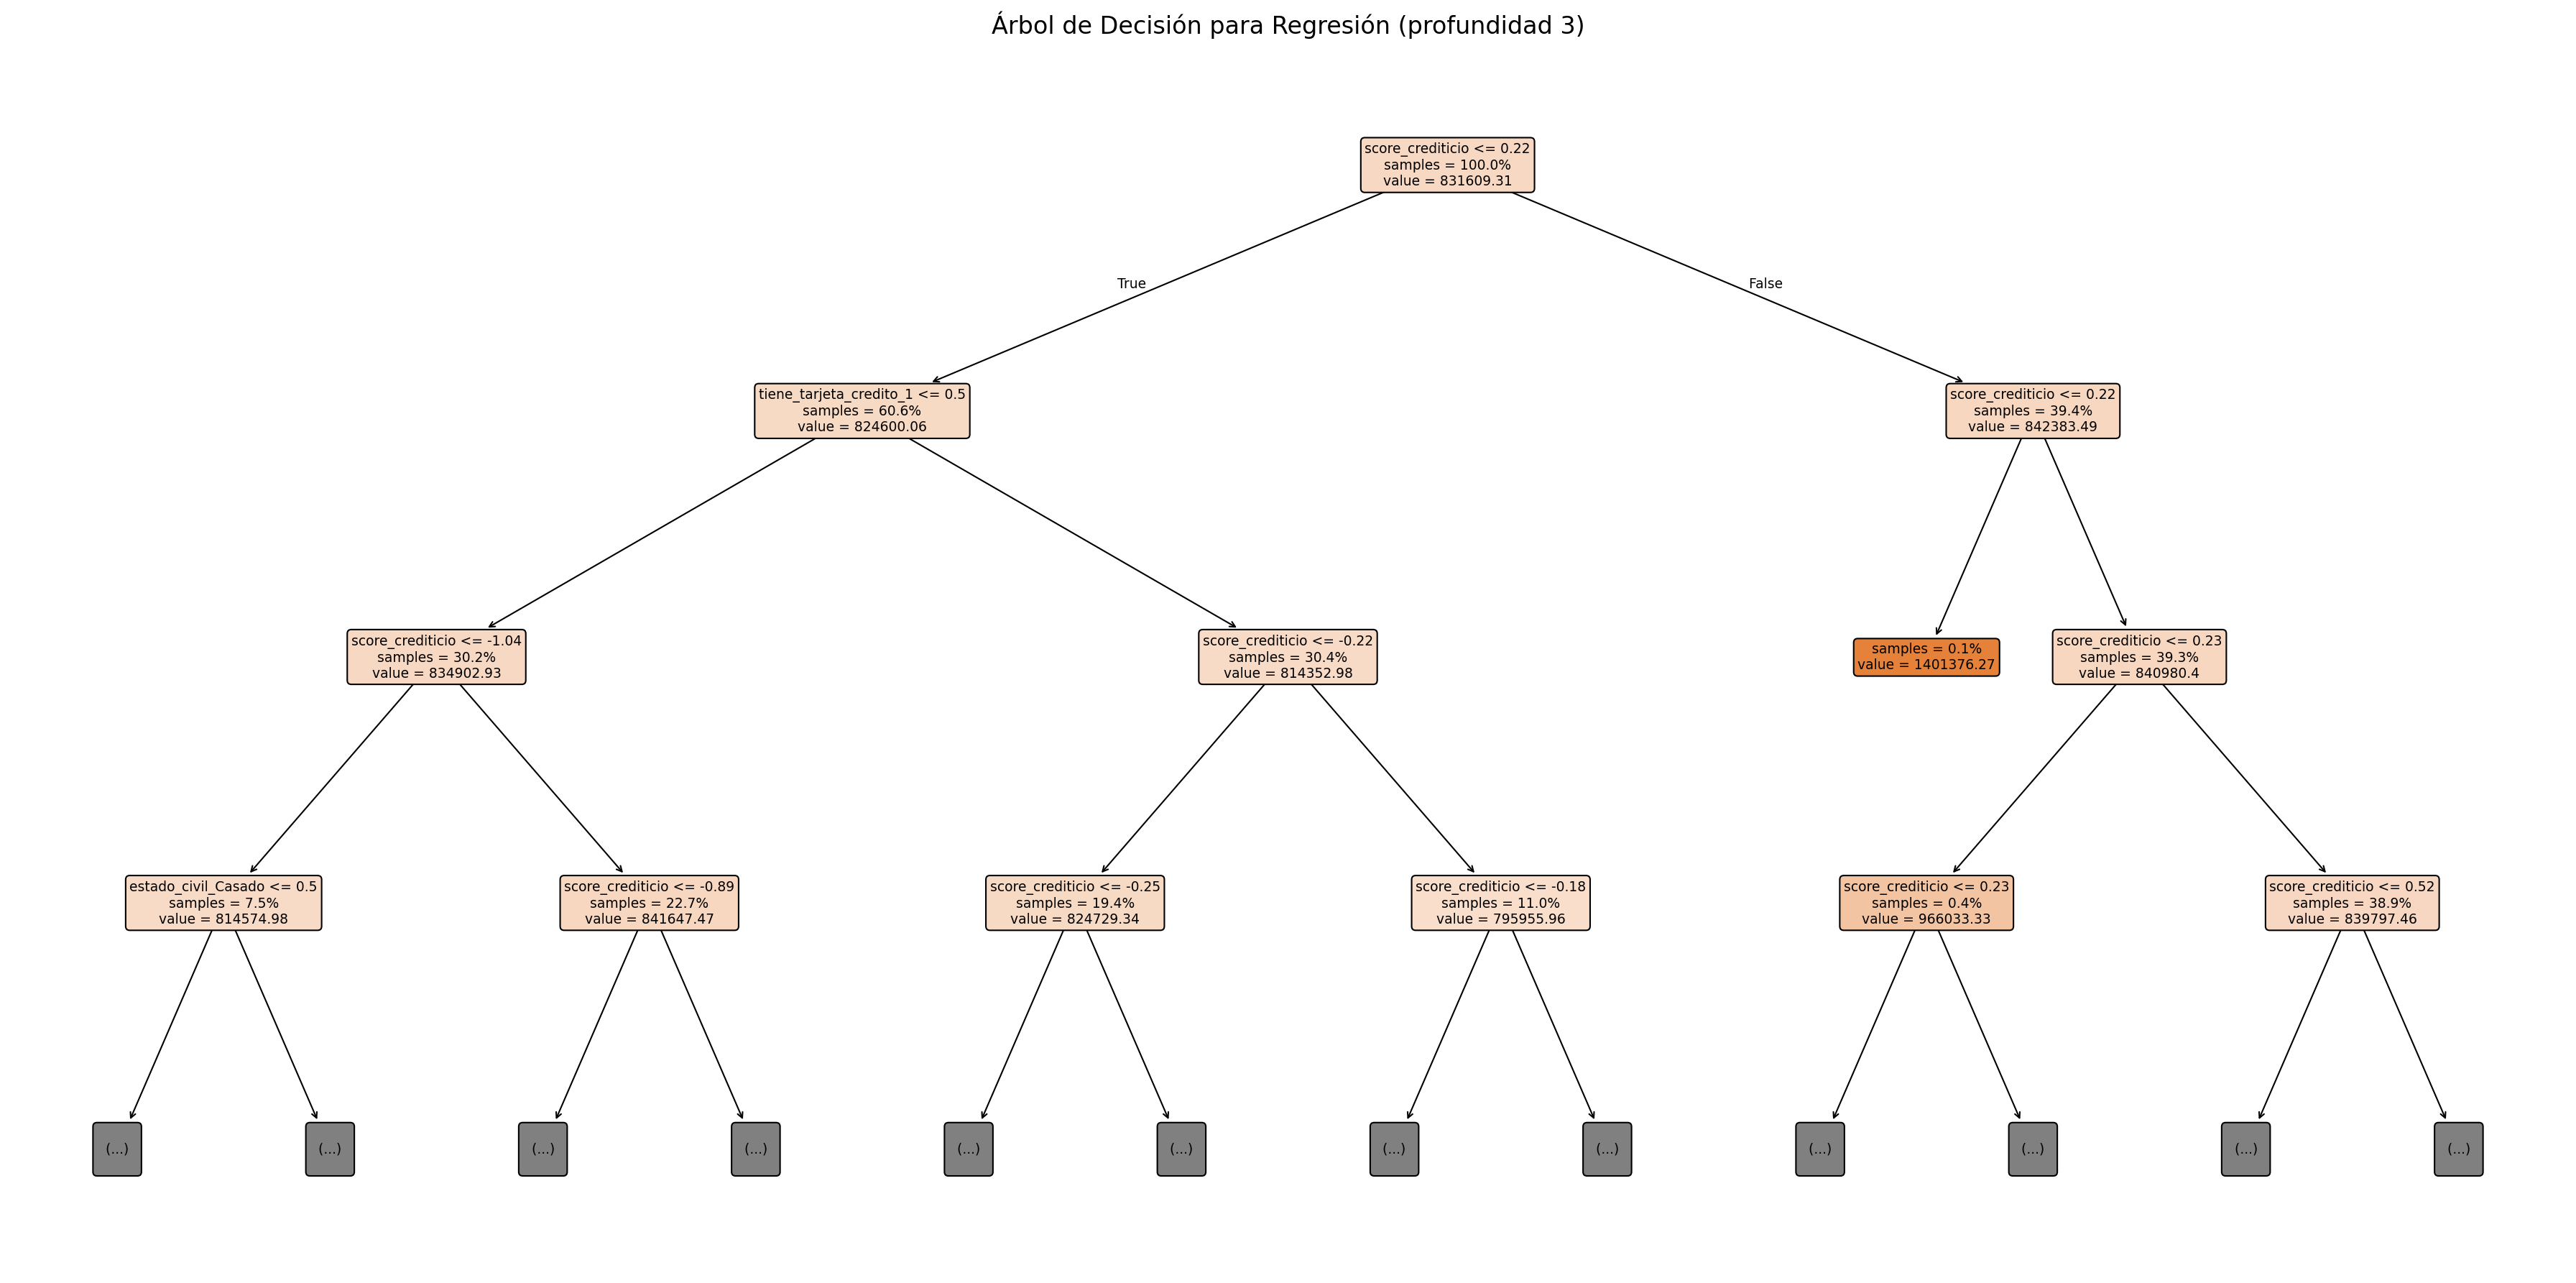

In [240]:
modelo_arbol = DecisionTreeRegressor(max_depth=7, min_samples_leaf=15, random_state=42)
modelo_arbol = modelo_arbol.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(24, 12), dpi=150)
plot_tree(
    modelo_arbol,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,
    impurity=False,
    proportion=True,
    precision=2,
    ax=ax,
 )

ax.set_title("Árbol de Decisión para Regresión (profundidad 3)", fontsize=16)
fig.tight_layout()
plt.show()